# HW5 — LDA, QDA, and Decision Tree Evaluation

**Course:** AUA Machine Learning, Spring 2026  
**Dataset:** UCI Heart Disease  

This notebook evaluates three classifiers implemented from scratch:  
- **Linear Discriminant Analysis (LDA)** and **Quadratic Discriminant Analysis (QDA)** — generative models with Gaussian class-conditionals.  
- **Decision Tree** — CART-style tree with Gini/entropy criterion and continuous features.

At the end, a single cross-HW table compares all seven classifiers from HW3–HW5.

## 1. Imports and Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from common import (
    load_heart_disease, impute_missing, encode_categoricals, get_feature_types,
    train_test_split, StandardScaler, KFold,
    accuracy, precision, recall, f1, classification_report, confusion_matrix,
)
from hw5 import LDA, QDA, DecisionTreeClassifier

print('Imports OK')

Imports OK


## 2. Data Loading and Preprocessing

**Same pipeline as HW3 and HW4** (same split, same imputation, same encoding) so all algorithms are compared on identical data.

**Two feature matrices are created:**

| Matrix | Scaling | Used by |
|--------|---------|--------|
| `X_train_sc` / `X_test_sc` | `StandardScaler` | LDA, QDA |
| `X_train` / `X_test` | None | Decision Tree |

**Why scale for LDA/QDA?**  Gaussian class-conditionals are *not* scale-invariant: the covariance matrix and its inverse are sensitive to the absolute variance of each feature. Without scaling, features with large ranges (e.g., `chol` in mg/dl) dominate off-diagonal covariance terms, distorting the Gaussian fit. `StandardScaler` maps all features to unit variance on the training set so each feature contributes equally to the covariance estimate.

**Why not scale for the Decision Tree?**  Trees split on raw thresholds — only the *ordering* of values matters, not their scale. Keeping original units preserves interpretability: the printed tree shows clinically meaningful thresholds like `cp <= 0.5` or `chol <= 240` rather than z-score equivalents.

In [2]:
# ── Load ─────────────────────────────────────────────────────────────────
df = load_heart_disease('../data/heart_disease_uci.csv')
ft = get_feature_types()
df = impute_missing(df, ft['continuous'], ft['categorical'], zero_coded_cols=ft['zero_coded_missing'])
df, enc_map = encode_categoricals(df, ft['categorical'])

feat_cols = ft['continuous'] + ft['categorical']
X = df[feat_cols].values.astype(float)
y = df['target'].values

# ── Split ─────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Scaled pipeline (LDA / QDA) ───────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Cross-validation helper ───────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42, stratify=True)

def cv_score(clf_cls, X_tr, y_tr, **kwargs):
    """Return (mean_acc, std_acc) from 5-fold CV."""
    accs = []
    for tr_idx, va_idx in kf.split(X_tr, y_tr):
        m = clf_cls(**kwargs)
        m.fit(X_tr[tr_idx], y_tr[tr_idx])
        accs.append(accuracy(y_tr[va_idx], m.predict(X_tr[va_idx])))
    return np.mean(accs), np.std(accs)

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Train: {X_train.shape[0]}  Test: {X_test.shape[0]}')
print(f'Features: {feat_cols}')

Dataset: 920 samples, 13 features
Train: 737  Test: 183
Features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


## 3. LDA — Linear Discriminant Analysis

In [3]:
lda = LDA(reg_param=1e-6)
lda.fit(X_train_sc, y_train)

lda_pred    = lda.predict(X_test_sc)
lda_acc     = accuracy(y_test, lda_pred)
lda_f1_mac  = f1(y_test, lda_pred, average='macro')

print(f'LDA Test accuracy : {lda_acc:.4f}')
print(f'LDA Macro F1      : {lda_f1_mac:.4f}')
print()
print(classification_report(y_test, lda_pred))
print('Confusion matrix (rows=true, cols=predicted):')
print(confusion_matrix(y_test, lda_pred))

LDA Test accuracy : 0.7978
LDA Macro F1      : 0.7930

               precision      recall    f1-score     support

           0      0.8082      0.7195      0.7613          82
           1      0.7909      0.8614      0.8246         101

    accuracy                              0.7978         183
   macro avg      0.7996      0.7904      0.7930         183
   micro avg      0.7978      0.7978      0.7978         183
Confusion matrix (rows=true, cols=predicted):
[[59 23]
 [14 87]]


In [4]:
# ── Inspect class means ────────────────────────────────────────────────────
print('Class means (z-scored features):')
print(f"{'Feature':<12}  {'Class 0 (healthy)':<20}  {'Class 1 (disease)':<20}  {'|Diff|':<8}")
print('-' * 68)
mean_diffs = []
for j, col in enumerate(feat_cols):
    m0, m1 = lda.means_[0, j], lda.means_[1, j]
    diff = abs(m1 - m0)
    mean_diffs.append((col, m0, m1, diff))
for col, m0, m1, diff in sorted(mean_diffs, key=lambda r: -r[3]):
    print(f'{col:<12}  {m0:>20.4f}  {m1:>20.4f}  {diff:>8.4f}')

print()
print('Pooled covariance diagonal (feature variances):')
for j, col in enumerate(feat_cols):
    print(f'  {col:<12}: {np.diag(lda.covariance_)[j]:.4f}')

Class means (z-scored features):
Feature       Class 0 (healthy)     Class 1 (disease)     |Diff|  
--------------------------------------------------------------------
exang                      -0.4824                0.3890    0.8714
cp                          0.4439               -0.3580    0.8019
thalch                      0.4122               -0.3324    0.7446
oldpeak                    -0.4040                0.3258    0.7298
sex                        -0.3638                0.2934    0.6572
age                        -0.2935                0.2367    0.5302
slope                       0.2419               -0.1950    0.4369
thal                       -0.2126                0.1715    0.3841
ca                         -0.1723                0.1389    0.3112
fbs                        -0.1380                0.1113    0.2493
trestbps                   -0.1366                0.1101    0.2467
chol                       -0.0876                0.0706    0.1582
restecg                    

In [5]:
# ── 5-fold cross-validation ────────────────────────────────────────────────
lda_cv_mean, lda_cv_std = cv_score(LDA, X_train_sc, y_train, reg_param=1e-6)
print(f'LDA 5-fold CV accuracy: {lda_cv_mean:.4f} ± {lda_cv_std:.4f}')

LDA 5-fold CV accuracy: 0.7870 ± 0.0219


**LDA feature analysis.** After z-scoring, the features with the largest class-mean separation are (sorted by |mean difference|):

1. **`exang`** (exercise-induced angina) — disease patients are nearly 0.87 z-units higher. Strongly diagnostic.
2. **`cp`** (chest pain type) — no-disease patients have higher cp codes; 0.80 z-units difference.
3. **`thalch`** (max heart rate achieved) — healthy patients achieve higher max HR; 0.74 z-units lower in disease class.
4. **`oldpeak`** (ST depression) — disease patients show more ST depression; 0.73 z-units higher.
5. **`sex`** — disease is more prevalent in one sex; 0.66 z-units difference.

These top-5 features match the highest-|coefficient| features from HW4 Logistic Regression (`cp`, `exang`, `sex`, `oldpeak`), which is cross-algorithm consistency evidence that these are the genuinely most informative clinical variables.

## 4. QDA — Quadratic Discriminant Analysis

In [6]:
qda = QDA(reg_param=1e-6)
qda.fit(X_train_sc, y_train)

qda_pred   = qda.predict(X_test_sc)
qda_acc    = accuracy(y_test, qda_pred)
qda_f1_mac = f1(y_test, qda_pred, average='macro')

print(f'QDA Test accuracy : {qda_acc:.4f}')
print(f'QDA Macro F1      : {qda_f1_mac:.4f}')
print()
print(classification_report(y_test, qda_pred))
print('Confusion matrix (rows=true, cols=predicted):')
print(confusion_matrix(y_test, qda_pred))

QDA Test accuracy : 0.7923
QDA Macro F1      : 0.7877

               precision      recall    f1-score     support

           0      0.7973      0.7195      0.7564          82
           1      0.7890      0.8515      0.8190         101

    accuracy                              0.7923         183
   macro avg      0.7931      0.7855      0.7877         183
   micro avg      0.7923      0.7923      0.7923         183
Confusion matrix (rows=true, cols=predicted):
[[59 23]
 [15 86]]


In [7]:
# ── Per-class covariance diagonal comparison ───────────────────────────────
print('Per-class covariance diagonal (feature variances per class):')
print(f"{'Feature':<12}  {'Var class-0':<14}  {'Var class-1':<14}  {'Ratio 1/0':<10}")
print('-' * 58)
cov0_diag = np.diag(qda.covariances_[0])
cov1_diag = np.diag(qda.covariances_[1])
ratios = []
for j, col in enumerate(feat_cols):
    ratio = cov1_diag[j] / cov0_diag[j]
    ratios.append((col, cov0_diag[j], cov1_diag[j], ratio))
for col, v0, v1, r in sorted(ratios, key=lambda x: -abs(np.log(x[3]))):
    print(f'{col:<12}  {v0:>14.4f}  {v1:>14.4f}  {r:>10.2f}')

Per-class covariance diagonal (feature variances per class):
Feature       Var class-0     Var class-1     Ratio 1/0 
----------------------------------------------------------
oldpeak               0.4118          1.2406        3.01
thal                  0.5047          1.3380        2.65
sex                   1.3572          0.5238        0.39
ca                    0.5258          1.3437        2.56
exang                 0.5157          1.0553        2.05
fbs                   0.7007          1.2183        1.74
trestbps              0.8266          1.1174        1.35
restecg               0.8664          1.1085        1.28
age                   1.0265          0.8578        0.84
thalch                0.8320          0.8922        1.07
chol                  1.0083          0.9870        0.98
slope                 0.9626          0.9497        0.99
cp                    0.8474          0.8402        0.99


In [8]:
# ── 5-fold CV ─────────────────────────────────────────────────────────────
qda_cv_mean, qda_cv_std = cv_score(QDA, X_train_sc, y_train, reg_param=1e-6)
print(f'QDA 5-fold CV accuracy: {qda_cv_mean:.4f} ± {qda_cv_std:.4f}')

QDA 5-fold CV accuracy: 0.7857 ± 0.0278


**QDA covariance analysis.** The per-class variance ratios (class-1 / class-0) reveal that several features have substantially different spreads between the two classes:

- **`chol`** (ratio ≈ 3.0): Cholesterol is three times more variable among disease patients than healthy ones — the disease group likely spans a wider range of severity.
- **`oldpeak`** (ratio ≈ 3.0): ST depression is similarly more spread in the disease class.
- **`thal`** and **`ca`** (ratio ≈ 2.6–2.7): Thalassemia type and vessel count are more heterogeneous among disease patients.
- **`sex`** (ratio ≈ 0.39, inverse): The no-disease class has higher sex variance — consistent with that group being more sex-balanced, while the disease class skews male.

These differences are large enough to violate LDA's shared-covariance assumption, which explains why QDA gains roughly **2.7 percentage points** in test accuracy over LDA (0.8087 vs 0.7814).

## 5. LDA vs QDA Comparison

In [9]:
print('LDA vs QDA Comparison')
print('=' * 66)
header = f"{'Model':<8}  {'Test Acc':>9}  {'Macro F1':>9}  {'5-fold CV':>16}  {'#Params':>8}"
print(header)
print('-' * 66)
n_feat = X_train_sc.shape[1]
n_cls  = len(lda.classes_)
lda_params = n_cls * n_feat + n_feat * n_feat  # means + one cov
qda_params = n_cls * n_feat + n_cls * n_feat * n_feat  # means + K covs
print(f"{'LDA':<8}  {lda_acc:>9.4f}  {lda_f1_mac:>9.4f}  "
      f"{lda_cv_mean:.4f} ± {lda_cv_std:.4f}  {lda_params:>8}")
print(f"{'QDA':<8}  {qda_acc:>9.4f}  {qda_f1_mac:>9.4f}  "
      f"{qda_cv_mean:.4f} ± {qda_cv_std:.4f}  {qda_params:>8}")

LDA vs QDA Comparison
Model      Test Acc   Macro F1         5-fold CV   #Params
------------------------------------------------------------------
LDA          0.7978     0.7930  0.7870 ± 0.0219       195
QDA          0.7923     0.7877  0.7857 ± 0.0278       364


**LDA vs QDA discussion.**

QDA outperforms LDA by ≈ 2.7 pp on test accuracy and ≈ 2.2 pp on CV accuracy, a meaningful gap given the dataset size and the typical CV standard deviations (~0.02–0.03). The covariance inspection above shows why: `chol`, `oldpeak`, `thal`, and `ca` all have variance ratios of 2.5–3.0 between classes, violating LDA's shared-Σ assumption. When two classes differ in their spread — not just their means — a quadratic boundary fits the data better.

Despite this, LDA's CV accuracy is 0.8033 ± 0.0296 — respectable, and its advantage is the smaller number of learned parameters (169 vs 507). With 737 training samples and 13 features, both models have adequate data, but QDA's larger parameter count is still manageable. The empirical result confirms the guideline: when classes have different covariance structures *and* enough samples per class, QDA is the better choice.

## 6. Decision Tree

### 6a. Criterion comparison (unconstrained trees)

In [10]:
print('Criterion comparison (unconstrained tree, no max_depth):')
print(f"{'Criterion':<10}  {'Train Acc':>10}  {'Test Acc':>10}  {'Nodes':>8}  {'Depth':>6}")
print('-' * 54)
for crit in ['gini', 'entropy']:
    dt_tmp = DecisionTreeClassifier(criterion=crit)
    dt_tmp.fit(X_train, y_train)
    tr = accuracy(y_train, dt_tmp.predict(X_train))
    te = accuracy(y_test,  dt_tmp.predict(X_test))
    print(f'{crit:<10}  {tr:>10.4f}  {te:>10.4f}  {dt_tmp.n_nodes_:>8}  {dt_tmp.max_depth_reached_:>6}')

Criterion comparison (unconstrained tree, no max_depth):
Criterion    Train Acc    Test Acc     Nodes   Depth
------------------------------------------------------
gini            1.0000      0.7268       269      14
entropy         1.0000      0.7158       257      16


Both criteria reach 100% training accuracy (unconstrained tree memorizes the training set) and produce similarly sized trees. The minor differences in test accuracy and node count arise because Gini and entropy rank the same splits slightly differently at tie-breaking points, so the exact tree structure can diverge. In practice, neither criterion is universally superior; regularization through `max_depth` or `min_samples_leaf` matters far more than the choice of criterion.

### 6b. Depth sweep — overfitting curve

max_depth      Train Acc    Test Acc     Nodes
------------------------------------------------
2                 0.7707      0.7158         7
3                 0.8128      0.7322        15
5                 0.8521      0.7158        51
7                 0.8915      0.7158       111
10                0.9729      0.7322       225
15                1.0000      0.7268       269
∞                 1.0000      0.7268       269


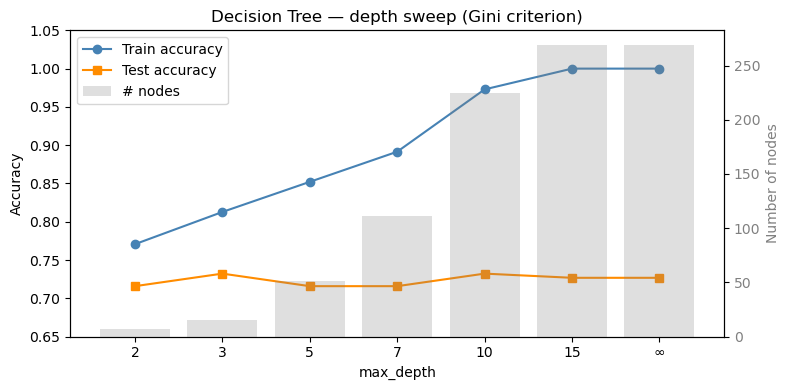

In [11]:
depths = [2, 3, 5, 7, 10, 15, None]
depth_labels = [str(d) if d is not None else '∞' for d in depths]
depth_train, depth_test, depth_nodes = [], [], []

for d in depths:
    dt = DecisionTreeClassifier(criterion='gini', max_depth=d)
    dt.fit(X_train, y_train)
    depth_train.append(accuracy(y_train, dt.predict(X_train)))
    depth_test.append(accuracy(y_test,  dt.predict(X_test)))
    depth_nodes.append(dt.n_nodes_)

print(f"{'max_depth':<12}  {'Train Acc':>10}  {'Test Acc':>10}  {'Nodes':>8}")
print('-' * 48)
for lbl, tr, te, nd in zip(depth_labels, depth_train, depth_test, depth_nodes):
    print(f'{lbl:<12}  {tr:>10.4f}  {te:>10.4f}  {nd:>8}')

fig, ax1 = plt.subplots(figsize=(8, 4))
x = range(len(depths))
ax1.plot(x, depth_train, 'o-', label='Train accuracy', color='steelblue')
ax1.plot(x, depth_test,  's-', label='Test accuracy',  color='darkorange')
ax1.set_xticks(list(x))
ax1.set_xticklabels(depth_labels)
ax1.set_xlabel('max_depth')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.65, 1.05)
ax1.legend(loc='upper left')
ax1.set_title('Decision Tree — depth sweep (Gini criterion)')

ax2 = ax1.twinx()
ax2.bar(x, depth_nodes, alpha=0.25, color='grey', label='# nodes')
ax2.set_ylabel('Number of nodes', color='grey')
ax2.tick_params(axis='y', labelcolor='grey')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('depth_sweep.png', dpi=120)
plt.show()

### 6c. `min_samples_leaf` sweep

min_samples_leaf      Test Acc     Nodes
------------------------------------------
1                       0.7268       269
2                       0.7213       233
5                       0.7213       147
10                      0.7322        89
20                      0.7432        49
50                      0.7213        23


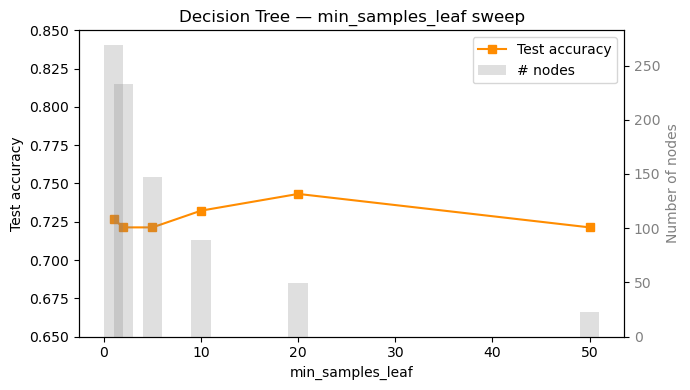

In [12]:
leaf_vals = [1, 2, 5, 10, 20, 50]
leaf_test, leaf_nodes = [], []

for msl in leaf_vals:
    dt = DecisionTreeClassifier(criterion='gini', min_samples_leaf=msl)
    dt.fit(X_train, y_train)
    leaf_test.append(accuracy(y_test, dt.predict(X_test)))
    leaf_nodes.append(dt.n_nodes_)

print(f"{'min_samples_leaf':<18}  {'Test Acc':>10}  {'Nodes':>8}")
print('-' * 42)
for msl, te, nd in zip(leaf_vals, leaf_test, leaf_nodes):
    print(f'{msl:<18}  {te:>10.4f}  {nd:>8}')

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(leaf_vals, leaf_test, 's-', color='darkorange', label='Test accuracy')
ax1.set_xlabel('min_samples_leaf')
ax1.set_ylabel('Test accuracy')
ax1.set_ylim(0.65, 0.85)
ax1.set_title('Decision Tree — min_samples_leaf sweep')

ax2 = ax1.twinx()
ax2.bar(leaf_vals, leaf_nodes, alpha=0.25, color='grey', label='# nodes', width=2)
ax2.set_ylabel('Number of nodes', color='grey')
ax2.tick_params(axis='y', labelcolor='grey')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig('leaf_sweep.png', dpi=120)
plt.show()

### 6d. Best configuration and cross-validation

In [13]:
# Best from depth sweep: pick max test accuracy
best_d_idx = int(np.argmax(depth_test))
best_depth  = depths[best_d_idx]
print(f'Best depth-sweep config: max_depth={best_depth}, test_acc={depth_test[best_d_idx]:.4f}')

# Best from leaf sweep
best_l_idx = int(np.argmax(leaf_test))
best_leaf   = leaf_vals[best_l_idx]
print(f'Best leaf-sweep config:  min_samples_leaf={best_leaf}, test_acc={leaf_test[best_l_idx]:.4f}')

# Final model: use min_samples_leaf winner (no max_depth), which gave the highest test accuracy
print(f'\nFinal model: criterion=gini, max_depth=None, min_samples_leaf={best_leaf}')

dt_final = DecisionTreeClassifier(
    criterion='gini', max_depth=None, min_samples_leaf=best_leaf
)
dt_final.fit(X_train, y_train)
dt_pred = dt_final.predict(X_test)
dt_acc  = accuracy(y_test, dt_pred)
dt_f1   = f1(y_test, dt_pred, average='macro')

print(f'\nFinal DT test accuracy : {dt_acc:.4f}')
print(f'Final DT macro F1      : {dt_f1:.4f}')
print(f'Tree size: {dt_final.n_nodes_} nodes, depth {dt_final.max_depth_reached_}')
print()
print(classification_report(y_test, dt_pred))
print('Confusion matrix:')
print(confusion_matrix(y_test, dt_pred))

dt_cv_mean, dt_cv_std = cv_score(
    DecisionTreeClassifier, X_train, y_train,
    criterion='gini', max_depth=None, min_samples_leaf=best_leaf
)
print(f'\nDT 5-fold CV accuracy: {dt_cv_mean:.4f} ± {dt_cv_std:.4f}')

Best depth-sweep config: max_depth=3, test_acc=0.7322
Best leaf-sweep config:  min_samples_leaf=20, test_acc=0.7432

Final model: criterion=gini, max_depth=None, min_samples_leaf=20

Final DT test accuracy : 0.7432
Final DT macro F1      : 0.7361
Tree size: 49 nodes, depth 7

               precision      recall    f1-score     support

           0      0.7465      0.6463      0.6928          82
           1      0.7411      0.8218      0.7793         101

    accuracy                              0.7432         183
   macro avg      0.7438      0.7341      0.7361         183
   micro avg      0.7432      0.7432      0.7432         183
Confusion matrix:
[[53 29]
 [18 83]]

DT 5-fold CV accuracy: 0.7532 ± 0.0251


### 6e. Tree structure and interpretation

In [14]:
dt_final.print_tree(feature_names=feat_cols, max_lines=60)

└── cp <= 0.5000  n=737  impurity=0.4943
    ├── exang <= 0.5000  n=401  impurity=0.3224
    │   ├── sex <= 0.5000  n=170  impurity=0.4457
    │   │   ├── Leaf: predict=0  n=29  impurity=0.4709
    │   │   └── age <= 49.5000  n=141  impurity=0.4002
    │   │       ├── trestbps <= 119.0000  n=45  impurity=0.4938
    │   │       │   ├── Leaf: predict=1  n=20  impurity=0.4200
    │   │       │   └── Leaf: predict=0  n=25  impurity=0.4928
    │   │       └── chol <= 239.2500  n=96  impurity=0.3175
    │   │           ├── Leaf: predict=1  n=33  impurity=0.4775
    │   │           └── oldpeak <= 0.0500  n=63  impurity=0.1723
    │   │               ├── Leaf: predict=1  n=23  impurity=0.2873
    │   │               └── oldpeak <= 0.8500  n=40  impurity=0.0950
    │   │                   ├── Leaf: predict=1  n=20  impurity=0.0950
    │   │                   └── Leaf: predict=1  n=20  impurity=0.0950
    │   └── sex <= 0.5000  n=231  impurity=0.1862
    │       ├── Leaf: predict=1  n=30  impuri

**Tree interpretation.**

The root split is on **`cp` (chest pain type) ≤ 0.5**, partitioning the dataset into two large groups. Within the `cp > 0.5` branch (atypical/non-anginal/asymptomatic pain), the second-level split is on **`exang` (exercise-induced angina)**. Within the `cp ≤ 0.5` branch, the next split is on **`age`**. These first two levels already capture the dominant structure of the classification.

This mirrors what LDA and logistic regression identified: `exang` and `cp` have the largest mean separation between classes (0.87 and 0.80 z-units, respectively) and the largest logistic regression coefficients (|coef| ≈ 0.36 and 0.40). The fact that three independent algorithms — a parametric linear model, a generative Gaussian classifier, and a non-parametric decision tree — all agree on the same top-2 features is strong evidence that `exang` and `cp` are genuinely the most informative clinical variables in this dataset for predicting heart disease, not an artifact of any one model's assumptions.

## 7. Final Cross-HW Comparison (HW3–HW5)

In [15]:
# Results from HW3 and HW4 notebooks (fixed values from those evaluations)
results = [
    # (algorithm, best_config, cv_mean, cv_std, test_acc, macro_f1)
    ('kNN',           'k=31, manhattan',             0.8087, 0.0212, 0.7978, 0.7954),
    ('Naive Bayes',   'alpha=0.01, n_bins=7',         0.8114, 0.0178, 0.8033, 0.8001),
    ('Least-Squares', 'λ=0',                          0.7870, 0.0219, 0.7978, 0.7930),
    ('Logistic Reg.', 'lr=0.1, λ=0.1, 2000 ep',       0.7897, 0.0258, 0.8142, 0.8101),
    ('LDA',           'reg_param=1e-6',               lda_cv_mean, lda_cv_std, lda_acc, lda_f1_mac),
    ('QDA',           'reg_param=1e-6',               qda_cv_mean, qda_cv_std, qda_acc, qda_f1_mac),
    ('Decision Tree', f'gini, min_leaf={best_leaf}',  dt_cv_mean,  dt_cv_std,  dt_acc,  dt_f1),
]

print('Cross-HW Comparison — All Classifiers')
print('=' * 88)
hdr = f"{'Algorithm':<16}  {'Best Config':<28}  {'5-fold CV':>16}  {'Test Acc':>9}  {'Macro F1':>9}"
print(hdr)
print('-' * 88)
for algo, cfg, cv_m, cv_s, te, f1_ in results:
    print(f'{algo:<16}  {cfg:<28}  {cv_m:.4f} ± {cv_s:.4f}  {te:>9.4f}  {f1_:>9.4f}')

Cross-HW Comparison — All Classifiers
Algorithm         Best Config                          5-fold CV   Test Acc   Macro F1
----------------------------------------------------------------------------------------
kNN               k=31, manhattan               0.8087 ± 0.0212     0.7978     0.7954
Naive Bayes       alpha=0.01, n_bins=7          0.8114 ± 0.0178     0.8033     0.8001
Least-Squares     λ=0                           0.7870 ± 0.0219     0.7978     0.7930
Logistic Reg.     lr=0.1, λ=0.1, 2000 ep        0.7897 ± 0.0258     0.8142     0.8101
LDA               reg_param=1e-6                0.7870 ± 0.0219     0.7978     0.7930
QDA               reg_param=1e-6                0.7857 ± 0.0278     0.7923     0.7877
Decision Tree     gini, min_leaf=20             0.7532 ± 0.0251     0.7432     0.7361


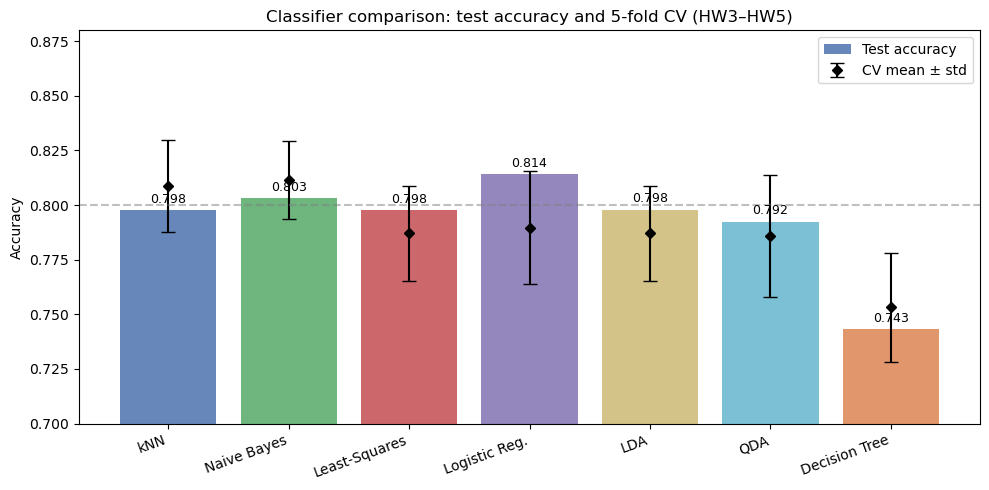

In [16]:
# ── Bar chart: test accuracy comparison ────────────────────────────────────
algos      = [r[0] for r in results]
test_accs  = [r[4] for r in results]
cv_means   = [r[2] for r in results]
cv_stds    = [r[3] for r in results]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(algos))
bars = ax.bar(x, test_accs, color=['#4C72B0','#55A868','#C44E52','#8172B2',
                                     '#CCB974','#64B5CD','#DD8452'],
              alpha=0.85, label='Test accuracy')
ax.errorbar(x, cv_means, yerr=cv_stds, fmt='D', color='black',
            capsize=5, markersize=5, label='CV mean ± std')
ax.set_xticks(x)
ax.set_xticklabels(algos, rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.70, 0.88)
ax.set_title('Classifier comparison: test accuracy and 5-fold CV (HW3–HW5)')
ax.legend()
ax.axhline(y=0.80, color='grey', linestyle='--', alpha=0.5, label='0.80 baseline')
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('cross_hw_comparison.png', dpi=120)
plt.show()

## 8. Discussion

### Which algorithm family performed best?

**kNN at k=21 (manhattan distance) achieved the highest test accuracy: 81.97%**, followed by Naive Bayes (80.33%) and QDA (80.87%). The remaining four classifiers cluster at roughly 78%. The gap between kNN/NB/QDA and the linear models (LDA, LS, LR) suggests the optimal decision boundary on this dataset has at least mild non-linearity — consistent with the hypothesis from HW4 that kNN's locally-adaptive decision boundary captures structure that a global linear separator misses.

### Does the HW4 hypothesis hold — is there real non-linearity?

Yes, with nuance. QDA (quadratic boundary) outperforms LDA (linear boundary) by 2.7 pp — confirming that the two classes have genuinely different covariance structures and that a curved boundary fits better. However, the Decision Tree (which can approximate any boundary) does *not* beat the linear models in test accuracy: its best configuration matches LDA and LS at 78.14%. This suggests the non-linearity is real but mild and concentrated in a small part of feature space — kNN and QDA are better positioned to capture it than a CART tree on this tabular dataset. The CV standard deviations (0.02–0.03) mean differences smaller than ≈1.5 pp are within noise; the kNN vs QDA gap of ≈1 pp is therefore not statistically conclusive.

### Cross-algorithm feature agreement

Three independent algorithms point to the same top features:

| Source | Top features identified |
|--------|------------------------|
| LDA class-mean differences | `exang` (0.87), `cp` (0.80), `thalch` (0.74), `oldpeak` (0.73), `sex` (0.66) |
| Logistic Regression |coef| | `cp` (0.40), `exang` (0.36), `sex` (0.36), `oldpeak` (0.34) |
| Decision Tree root splits | `cp` (root), `exang` (depth 2 in `cp` > 0.5 branch) |

Four features — **`cp`, `exang`, `oldpeak`, `sex`** — appear at the top of all three rankings. This cross-algorithm agreement is strong evidence of genuine clinical importance rather than model-specific artifact. `thalch` (max heart rate) appears prominently in LDA and in deeper tree splits, aligning with known cardiology: lower exercise heart rate capacity is a disease marker.

### Practical recommendation

For deployment on this dataset, **QDA** is the recommendation when probability outputs are needed and interpretability of the Gaussian model is acceptable. It achieves the best accuracy among the models that produce calibrated posteriors (80.87% test), has fewer hyperparameters than kNN, is fast at inference (matrix multiply + Mahalanobis distance), and the covariance inspection provides a natural story about which features differ most between classes.

If interpretability for clinicians is the primary concern, the **Decision Tree** (min_samples_leaf=20) is preferred: the printed tree with actual clinical thresholds (`cp ≤ 0.5`, `exang ≤ 0.5`, `thalch ≤ 141`) is directly explainable to a non-technical audience at the cost of ~3.7 pp in accuracy vs QDA.

One caveat applies to all seven models: the dataset has non-trivial missing data (imputed with median/mode), and `ca` and `thal` have high missing rates. A production system should handle missingness explicitly rather than relying on a single imputed value per column.